# Data / Model Init

In [1]:
N_SAMPLES = 10000
# N_SAMPLES = None
random_state = 11
fold_id = 0

FILTERS = {
    "duration_unit": ["h"],
    "effect": ["MOR", "POP", "GRO", "BEH", "REP", "ITX", "PHY", "DVP", "MPH"],
}

SPLIT_SALTS = False
REMOVE_LONE = False
REMOVE_METALS = False

MAX_CONC_VALUE = 10000
DURATION_FILL_VALUE = 1e-6
MAX_DURATION_HOURS = 9000.0

%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    possible = Path.cwd() / "vollmers/gnn-thesis/gnn-thesis"
    if (possible / "src").exists():
        PROJECT_ROOT = possible

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils.smiles import from_smiles

from src.data.io import load_data
from src.data.cleaning import process_data, print_mol_types
from src.data.graph_building import build_graphs
from src.data.metadata import sequential_encoder, build_config
from src.data.cleaning import fragment_count, is_salt, has_metal, is_single_node
from src.data.splitting import butina_split, show_split_info
from src.data.sampling import LoadData, show_loader_info, display_sampling_effect
from src.training.loops import train
from src.visualization.training_plots import  plot_training, plot_training_metrics, plot_group_training


pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

print("Imports imported")


/home/vollmers/.conda/envs/gnn-m/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports imported


In [2]:
DATA_PATH = PROJECT_ROOT / "Data" / "toxicity_all.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data file not found: {DATA_PATH}")

print(f"Data path: {DATA_PATH}")

df_all = load_data(DATA_PATH)

df_processed = process_data(
    df_all,
    n_samples=N_SAMPLES,
    random_state=random_state,
    filters=FILTERS,
    require_duration=False,
    require_taxid=True,
    split_salts=SPLIT_SALTS,
    remove_lone=REMOVE_LONE,
    remove_metals=REMOVE_METALS,
    max_conc_value=MAX_CONC_VALUE,
    duration_fill_value=DURATION_FILL_VALUE,
    max_duration_hours=MAX_DURATION_HOURS,
    log_transform_duration=True,
    keep_duration_raw=True,
)

df_processed


Data path: /home/vollmers/gnn-thesis/Data/toxicity_all.csv
Filters
conc > 0 and <= 10000
True: 0.990
duration_unit: ['h']
True: 0.980
effect: ['MOR', 'POP', 'GRO', 'BEH', 'REP', 'ITX', 'PHY', 'DVP', 'MPH']
True: 0.981
require_taxid: True
True: 0.995
duration <= 9000.0 h or missing
True: 0.986

Loaded and masked training data
Rows in full data: 561,100
Rows after mask: 525,852
Rows before preprocessing: 525,852
Rows after preprocessing:  525,852
Rows removed: 0


,SK_unique_id,species_common_name,species_latin_name,CAS,chemical_name,conc_unit,conc,duration,duration_unit,effect,endpoint,SMILES,organism_lifestage,administration_route,species_sci_name,taxid,superkingdom,kingdom,phylum,subphylum,class,order,family,genus,species,species_group,log10c,duration_raw
0,AQTER1194716,Two-Spotted Spider Mite,tetranychus urticae,2312-35-8,"2-[4-(1,1-Dimethylethyl)phenoxy]cyclohexyl 2-propynyl ester sulfurous acid",mg/L,1437.912,1.681241,h,MOR,EC50,C#CCOS(=O)OC1CCCCC1Oc1ccc(C(C)(C)C)cc1,adult,soaking,tetranychus urticae,32264,2759.0,33208.0,6656.0,6843.0,6854.0,83136.0,32262.0,32263.0,32264.0,insects,3.157732,48.0
1,AQTER700564,Ciliate,tetrahymena pyriformis,1423-60-5,3-Butyn-2-one,mg/L,0.176,1.662758,h,POP,EC50,C#CC(C)=O,adult,static,tetrahymena pyriformis,5908,2759.0,NaN,5878.0,431838.0,6020.0,31277.0,291294.0,5890.0,5908.0,protozoans,-0.754487,46.0
2,AQTER1155713,Wild Portulaca,portulaca oleracea,8069-49-6,"1,3-Dichloro-1-propene mixt. with trichloronitromethane",kg/m2,0.025,3.772908,h,POP,LOEC,ClC=CCCl.O=[N+]([O-])C(Cl)(Cl)Cl,adult,environmental,portulaca oleracea,46147,2759.0,33090.0,35493.0,131221.0,3398.0,3524.0,3581.0,3582.0,46147.0,plants,-1.602060,5928.0
3,AQTER693103,San Paulo Shrimp,penaeus paulensis,7664-41-7,Ammonia,mg/L,21.980,1.982271,h,MOR,EC50,N,early,fill,penaeus paulensis,71413,2759.0,33208.0,6656.0,6657.0,6681.0,6683.0,6685.0,133894.0,71413.0,crustaceans,1.342028,96.0
4,AQTER579917,Midge,chironomus tentans,1420-04-8,"5-Chloro-N-(2-chloro-4-nitrophenyl)-2-hydrozybenzamide, compd. with 2-aminoe...",mg/L,0.228,1.982271,h,ITX,EC50,NCCO.O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,adult,static,chironomus tentans,7153,2759.0,33208.0,6656.0,6960.0,50557.0,7147.0,7149.0,7150.0,7153.0,insects,-0.642065,96.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,RTECS370753,mouse,Mus musculus,101-05-3,"s-Triazine, 2,4-dichloro-6-(o-chloroanilino)-",mg/kg,6020.000,-6.000000,h,MOR,EC50,Clc1nc(Cl)nc(Nc2ccccc2Cl)n1,adult,fill,mus musculus,10090,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10088.0,10090.0,rodents,3.779596,NaN
9996,AQTER535544,Pond Snail,lymnaea acuminata,315-18-4,"4-(Dimethylamino)-3,5-dimethylphenol, Methylcarbamate(ester)",mg/L,1.200,2.225309,h,MOR,EC50,CNC(=O)Oc1cc(C)c(N(C)C)c(C)c1,adult,static,radix acuminata,1804063,2759.0,33208.0,6447.0,NaN,6448.0,NaN,6521.0,55689.0,1804063.0,mollusks,0.079181,168.0
9997,RTECS300881,mouse,Mus musculus,758-42-9,"2-Propanone, 1,1,1-trichloro-3,3,3-trifluoro-",mg/kg,260.000,-6.000000,h,MOR,EC50,O=C(C(F)(F)F)C(Cl)(Cl)Cl,adult,fill,mus musculus,10090,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10088.0,10090.0,rodents,2.414973,NaN
9998,AQTER720400,Mozambique Tilapia,oreochromis mossambicus,55-38-9,"O,O-Dimethyl O-[3-methyl-4-(methylthio)phenyl]ester phosphorothioic acid",ppm,4.190,1.681241,h,MOR,EC50,COP(=S)(OC)Oc1ccc(SC)c(C)c1,mid,static,oreochromis mossambicus,8127,2759.0,33208.0,7711.0,89593.0,186623.0,1489911.0,8113.0,8139.0,8127.0,fish,0.622214,48.0


In [3]:
from src.data.simple_featurizer import simple_featurizer
from src.data.features_graph import GraphFeaturizer

ATOM_FEATURES = (
    "atomic_num",
    "degree",
    "formal_charge",
    "num_hs",
    "hybridization",
    "is_aromatic",
    "is_in_ring",
    "atomic_mass",
    "period",
    "group",
    "covalent_radius",
    "vdw_radius",
    "is_metal",
)

BOND_FEATURES = (
    "bond_order",
    "is_conjugated",
    "is_in_ring",
    "stereo",
)

graph_featurizer = GraphFeaturizer(ATOM_FEATURES, BOND_FEATURES)

df_processed["features"] = df_processed["SMILES"].apply(graph_featurizer.featurize)

graph_cache = graph_featurizer.get_graph_cache()

from src.data.features_mol import add_molecule_metadata

MOLECULE_CATEGORICAL_COLS = [
    "is_salt",
    "has_metal",
    "is_single_node",
]

MOLECULE_NUMERICAL_COLS = [
    "fragment_count",
    # "mol_weight",
    "log10_mol_weight",
    # "logp",
    # "tpsa",
    # "log10_tpsa_plus1",
    # "h_bond_donor_count",
    # "h_bond_acceptor_count",
    # "heavy_atom_count",
    # "log10_heavy_atom_count_plus1",
    # "hetero_atom_count",
    # "halogen_count",
    # "metal_count",
    # "transition_metal_count",
    # "ring_count",
    # "aromatic_ring_count",
    # "rotatable_bond_count",
    "formal_charge",
]

# Add molecule-level metadata for categorical and numerical encoders
df_processed = add_molecule_metadata(df_processed, categorical_cols=MOLECULE_CATEGORICAL_COLS, numerical_cols=MOLECULE_NUMERICAL_COLS)

USE_PRETRAINED_TAXID = True
PRETRAINED_TAXID_PATH = PROJECT_ROOT / "Data" / "moredata" / "pretrained_tax_emb.pkl.zip"
print(f"Pretrained taxid path: {PRETRAINED_TAXID_PATH}")

config_tax = {}

# Categorical encoding
exp_categorical_cols = [
    "species_group",
    "conc_unit",
    "endpoint", 
    "effect"
]

CATEGORICAL_COLS = exp_categorical_cols + MOLECULE_CATEGORICAL_COLS

df_categorical = df_processed[CATEGORICAL_COLS].copy()
df_categorical, categorical_encoder = sequential_encoder(df_categorical, CATEGORICAL_COLS)
# df_categorical now contains only the sequential data for selected columns

config_categorical = build_config(df_categorical, CATEGORICAL_COLS)

species_group_decoder = {encoded: original for original, encoded in categorical_encoder["species_group"].items()}

NUMERICAL_COLS = MOLECULE_NUMERICAL_COLS

graphs = build_graphs(
    df_processed,  
    df_categorical,
    CATEGORICAL_COLS,
    NUMERICAL_COLS,
    )

from src.data.splitting import _build_dataset

full_dataset = _build_dataset(graphs, range(len(graphs)))

Pretrained taxid path: /home/vollmers/gnn-thesis/Data/moredata/pretrained_tax_emb.pkl.zip


In [4]:
from src.models.pna import compute_pna_degree_histogram

from src.models.grapefruit import Grapefruit
from src.models.toxicity_model import ToxicityModel
from src.models.meta_encoder import MetaEncoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

########## MODEL HYPERPARAMETERS ##########

PRETRAINED_TAX_DIM = 768 # 768 is the length of the vectors in pretrained_tax_emb.pkl.zip
PRETRAINED_TAXID_OUTPUT_DIM = 512
CATEGORICAL_DIM = 128
NUMERIC_DIM = 128
META_DROPOUT = 0.3

GNN_HIDDEN_DIM = 256
GNN_OUT_DIM = 512
TOWERS = 4

NUM_LAYERS = 3
NUM_TIMESTEPS = 2
DROPOUT = 0.3

FINAL_HIDDEN_DIM = 1024

ATOM_FEATURE_DIM = graphs[0].x.shape[1]
EDGE_FEATURE_DIM = graphs[0].edge_attr.shape[1]
VIRTUAL_EDGE_FEATURE_DIM = graphs[0].virtual_edge_attr.shape[1] if hasattr(graphs[0], "virtual_edge_attr") else 0

def build_model():
    meta_encoder = MetaEncoder(
        pretrained_taxid_path=PRETRAINED_TAXID_PATH if USE_PRETRAINED_TAXID else None,
        pretrained_tax_dim=PRETRAINED_TAX_DIM,
        pretrained_taxid_output_dim=PRETRAINED_TAXID_OUTPUT_DIM,
        config_categorical=config_categorical,
        categorical_output_dim=CATEGORICAL_DIM,
        numerical_columns=NUMERICAL_COLS,
        numeric_output_dim=NUMERIC_DIM,
        dropout=META_DROPOUT
    ).to(device)

    # meta_encoder = None

    pna_deg = compute_pna_degree_histogram(full_dataset)

    model_gnn = Grapefruit(
        in_channels=ATOM_FEATURE_DIM,
        edge_dim=EDGE_FEATURE_DIM,
        virtual_edge_dim=VIRTUAL_EDGE_FEATURE_DIM,
        hidden_dim=GNN_HIDDEN_DIM,
        towers=TOWERS,
        deg=pna_deg,
        out_dim=GNN_OUT_DIM,
        num_layers=NUM_LAYERS,
        num_timesteps=NUM_TIMESTEPS,
        dropout=DROPOUT,
    ).to(device)

    # model_gnn = None

    model = ToxicityModel(
        model_gnn,
        meta_encoder,
        hidden_dim=FINAL_HIDDEN_DIM,
    ).to(device)

    n_params_meta = sum(p.numel() for p in meta_encoder.parameters() if p.requires_grad) if meta_encoder else 0
    n_params_gnn = sum(p.numel() for p in model_gnn.parameters() if p.requires_grad) if model_gnn else 0
    n_params_total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    gnn_name = type(model_gnn).__name__ if model_gnn is not None else "metadata_only"

    return model, meta_encoder, model_gnn, n_params_meta, n_params_gnn, n_params_total, gnn_name

model, meta_encoder, model_gnn, *_ = build_model()

checkpoint_path = PROJECT_ROOT / "outputs" / "models" / "Grapefruit-9M-150-fold0.pt"

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

model.eval()

print(f"Loaded model from {checkpoint_path}")
print(f"Best epoch: {checkpoint.get('best_epoch')}")
print(f"Best score: {checkpoint.get('best_monitor_value')}")

Loaded model from /home/vollmers/gnn-thesis/outputs/models/Grapefruit-9M-150-fold0.pt
Best epoch: 105
Best score: 0.7136323903370829


# Interpretability

## Mol heatmaps

In [5]:
from torch_geometric.data import Data
from torch import nn

class ExplainerWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(
        self,
        x,
        edge_index,
        edge_attr=None,
        virtual_edge_index=None,
        virtual_edge_attr=None,
        fragment_id=None,
        batch=None,
    ):
        data = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            virtual_edge_index=virtual_edge_index,
            virtual_edge_attr=virtual_edge_attr,
            fragment_id=fragment_id,
            batch=batch,
        )
        return self.model(data)

In [15]:
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer, AttentionExplainer

algorithm = GNNExplainer(epochs=100)
# algorithm = AttentionExplainer

explainer = Explainer(
    model=ExplainerWrapper(model_gnn),
    algorithm=algorithm,
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type=None,
    model_config=dict(
        mode="regression",
        task_level="graph",
    )
)

graph = graphs[0].to(device)

if not hasattr(graph, "batch") or graph.batch is None:
    graph.batch = torch.zeros(graph.x.size(0), dtype=torch.long, device=graph.x.device)

explanation = explainer(
    graph.x,
    graph.edge_index,
    edge_attr=graph.edge_attr,
    virtual_edge_index=graph.virtual_edge_index,
    virtual_edge_attr=graph.virtual_edge_attr,
    fragment_id=graph.fragment_id,
    batch=graph.batch,
)



In [16]:
import torch
from IPython.display import display

print(graph.smiles)
print(graph)
print()
print(explanation) # node_mask shape: [num_nodes, num_node_features] - "how important each atoms node feature was for the prediction"
print()

node_mask = explanation.node_mask.cpu().detach().numpy()
node_importance = node_mask.sum(axis=1)
print(node_importance)
feature_importance = node_mask.sum(axis=0)

C#CCOS(=O)OC1CCCCC1Oc1ccc(C(C)(C)C)cc1
Data(x=[24, 187], edge_index=[2, 50], edge_attr=[50, 14], virtual_edge_index=[2, 0], virtual_edge_attr=[0, 10], fragment_id=[24], num_fragments=[1], smiles='C#CCOS(=O)OC1CCCCC1Oc1ccc(C(C)(C)C)cc1', y=3.1577322483062744, row_id=0, taxid_raw=32264, species_group=0, conc_unit=0, endpoint=0, effect=0, is_salt=0, has_metal=0, is_single_node=0, fragment_count=1.0, log10_mol_weight=2.5442605018615723, formal_charge=0.0, batch=[24])

Explanation(node_mask=[24, 187], prediction=[1, 512], target=[1, 512], x=[24, 187], edge_index=[2, 50], edge_attr=[50, 14], virtual_edge_index=[2, 0], virtual_edge_attr=[0, 10], fragment_id=[24], batch=[24])

[3.68111   3.5186598 3.5593023 3.8414304 3.5118117 3.5900037 3.6580007
 3.8047545 3.5397582 3.642753  3.5776372 3.5019646 3.513363  3.613285
 3.5433362 3.6475883 3.7674553 3.621561  3.7256439 3.6391609 3.6098015
 3.6138172 3.8125834 3.7073624]


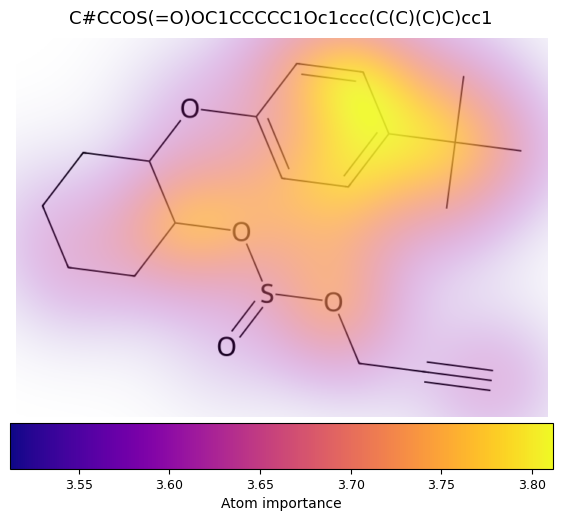

In [17]:
from src.visualization.interpretability import draw_atom_heatmap_gaussian

scores = draw_atom_heatmap_gaussian(
    graph.smiles,
    explanation,
    reduce="sum_abs",
    cmap_name="plasma",
    sigma_frac=0.1,
    alpha=0.90,
)


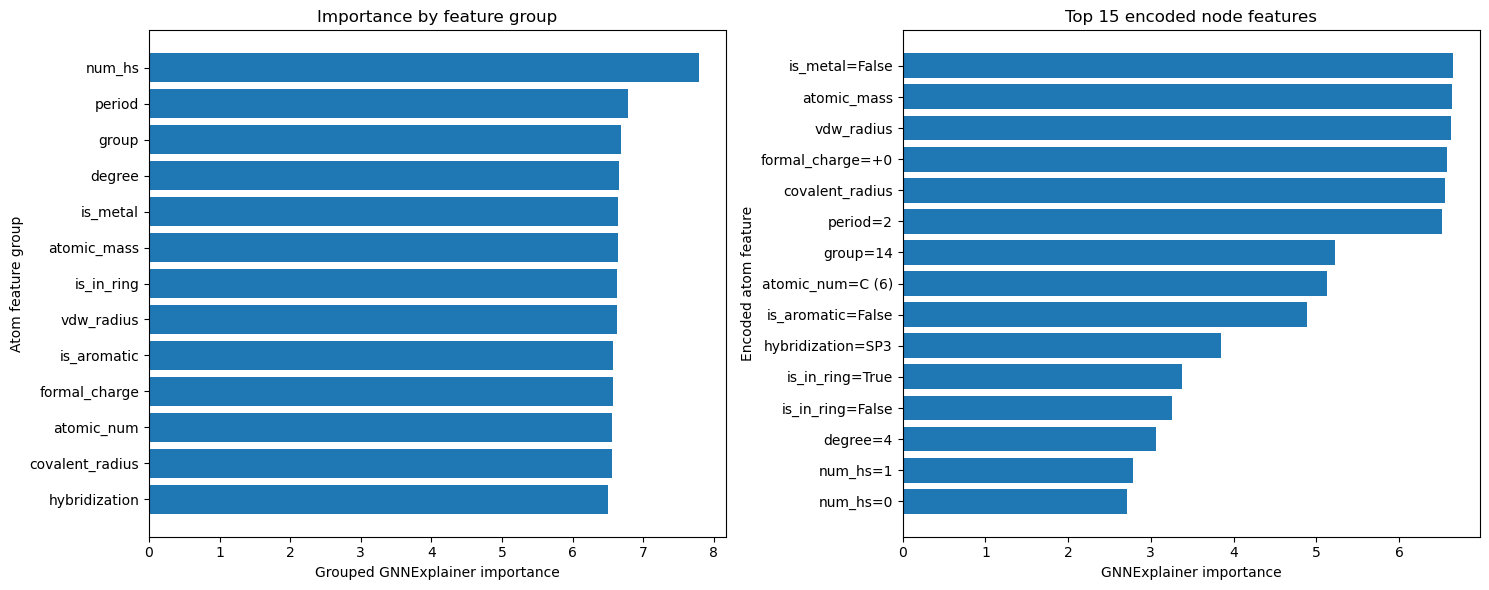

In [18]:
from src.visualization.interpretability import build_atom_feature_index, plot_node_feature_importance

feature_index, feature_blocks = build_atom_feature_index(graph_featurizer.atom_features) # For decoding features

feature_index, feature_blocks = plot_node_feature_importance(explanation, graph, feature_index, top_n=15, figsize=(15, 6))

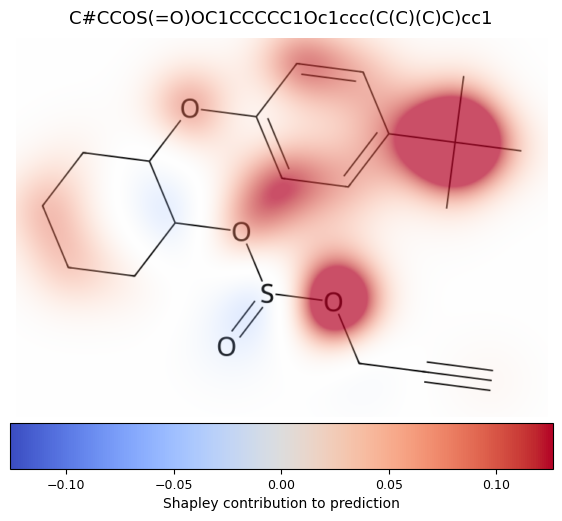

array([ 0.02253167,  0.00499165, -0.03466495,  0.20118102, -0.07603943,
       -0.02571113,  0.08802357, -0.05763143,  0.02833603,  0.05636871,
        0.06530758,  0.02496898, -0.02635279,  0.09825971, -0.02480863,
        0.09737881,  0.05520076,  0.05061809,  0.20448847,  0.01783638,
        0.02253075,  0.02697011,  0.05556564,  0.10010418])

In [19]:
from src.visualization.interpretability import atom_shapley_random, draw_atom_shapley_heatmap_gaussian

shapley = atom_shapley_random(model, graph)

draw_atom_shapley_heatmap_gaussian(
    graph.smiles,
    shapley,
    cmap_name="coolwarm",
    sigma_frac=0.07,
    save_path="atom_shapley_heatmap.png",
)

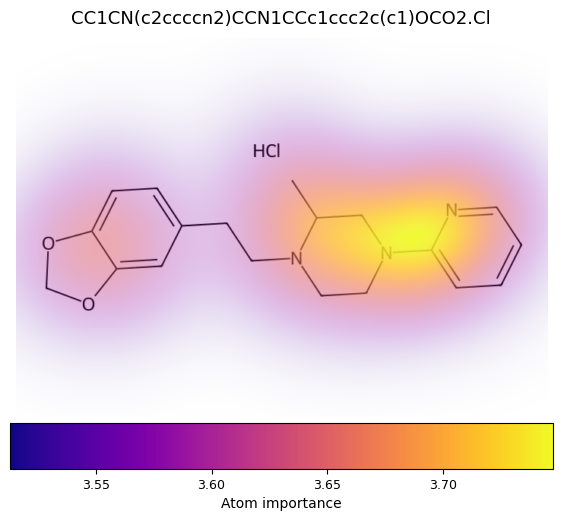

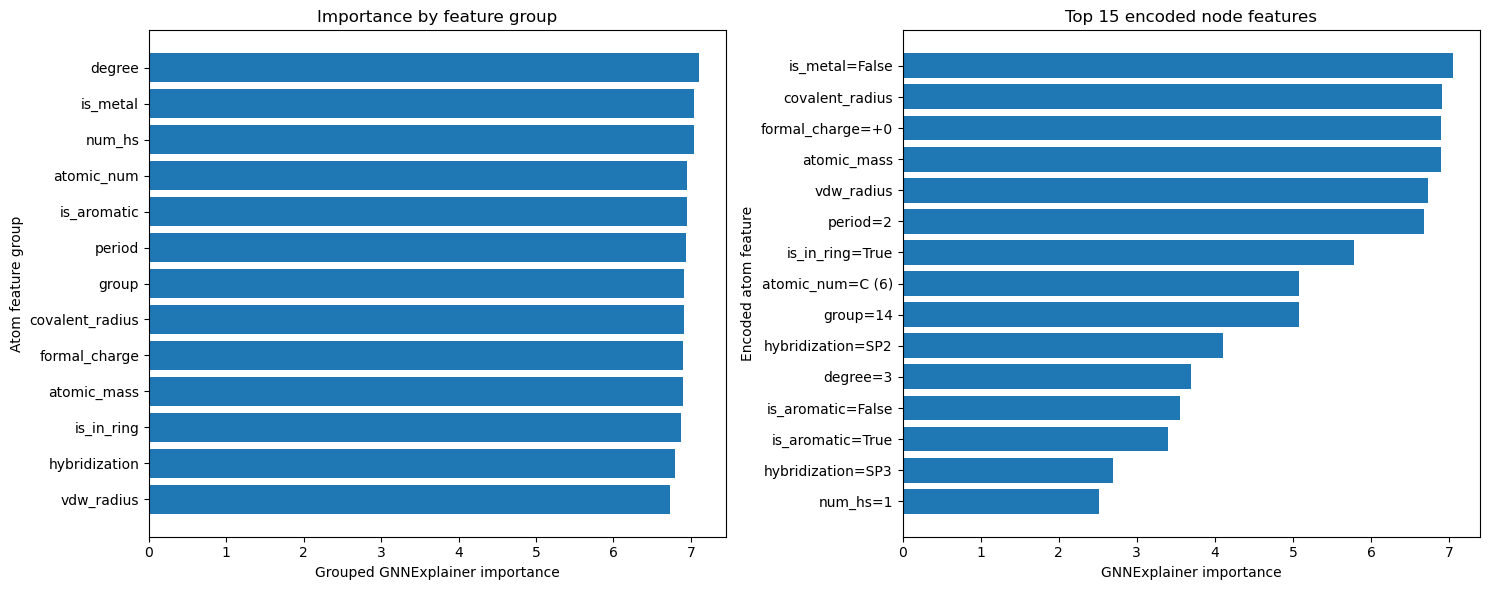

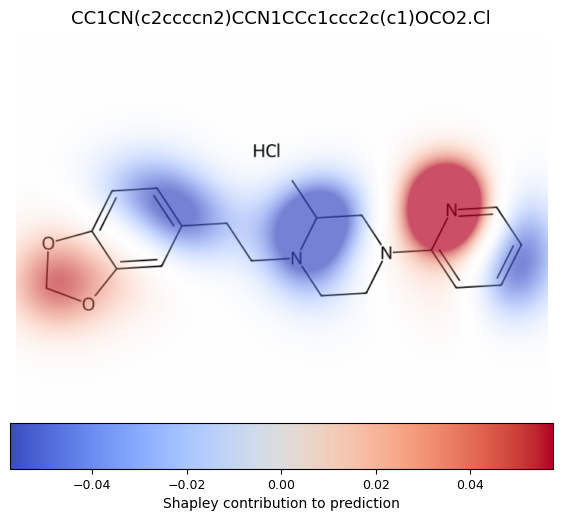

array([-0.00031588, -0.05869132, -0.01826572,  0.02488154, -0.02877528,
        0.03276614, -0.04537443, -0.03025055, -0.03806232,  0.14567508,
       -0.00494738, -0.01053897, -0.03107708,  0.00380181, -0.01316694,
       -0.04303459, -0.02645897, -0.02152353,  0.00779518,  0.01336046,
        0.01396257,  0.01128089,  0.03746675,  0.01105955,  0.00233485])

In [20]:
graph = graphs[390].to(device)

if not hasattr(graph, "batch") or graph.batch is None:
    graph.batch = torch.zeros(graph.x.size(0), dtype=torch.long, device=graph.x.device)

explanation = explainer(
    graph.x,
    graph.edge_index,
    edge_attr=graph.edge_attr,
    virtual_edge_index=graph.virtual_edge_index,
    virtual_edge_attr=graph.virtual_edge_attr,
    fragment_id=graph.fragment_id,
    batch=graph.batch,
)

scores = draw_atom_heatmap_gaussian(
    graph.smiles,
    explanation,
    reduce="sum_abs",
    cmap_name="plasma",
    sigma_frac=0.1,
    alpha=0.90,
)

feature_index, feature_blocks = build_atom_feature_index(graph_featurizer.atom_features) # For decoding features

feature_index, feature_blocks = plot_node_feature_importance(explanation, graph, feature_index, top_n=15, figsize=(15, 6))


shapley = atom_shapley_random(model, graph)

draw_atom_shapley_heatmap_gaussian(
    graph.smiles,
    shapley,
    cmap_name="coolwarm",
    sigma_frac=0.07,
    save_path="atom_shapley_heatmap.png",
)

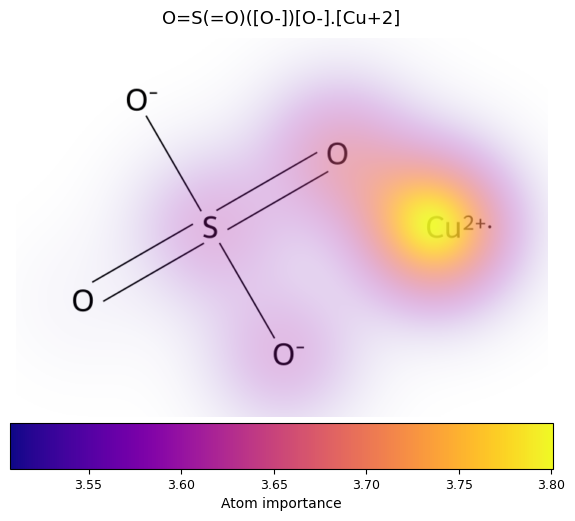

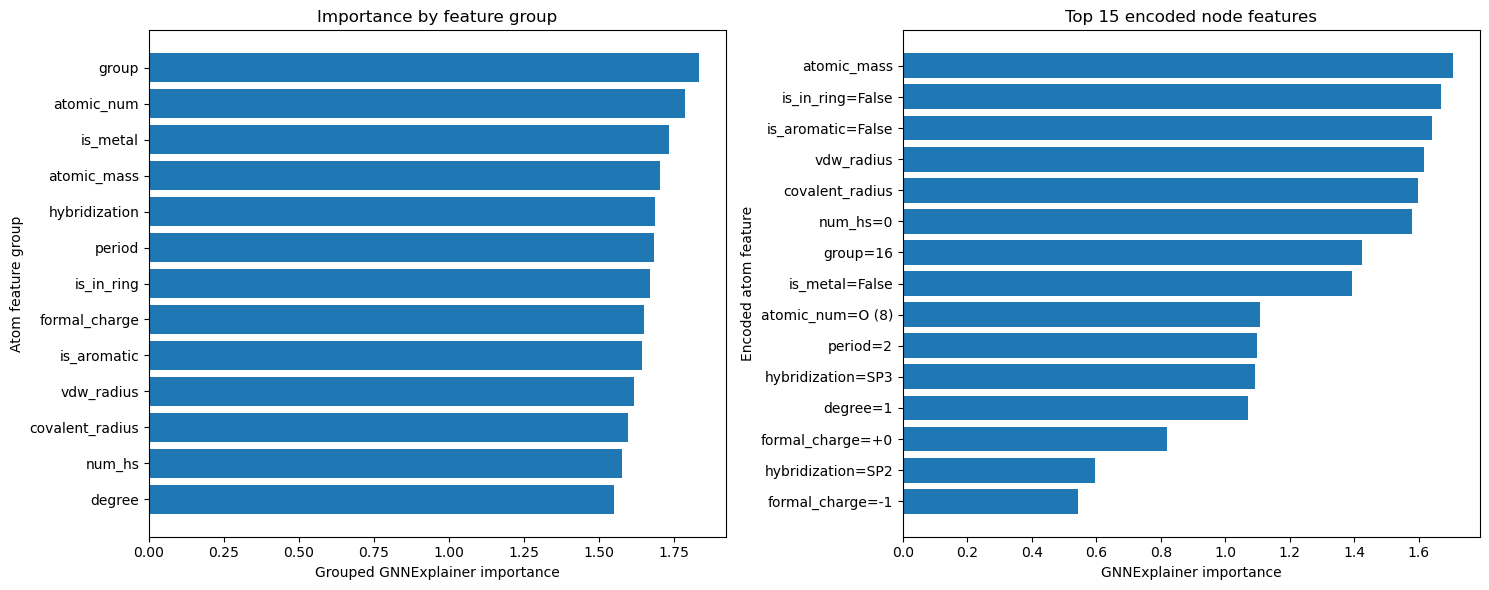

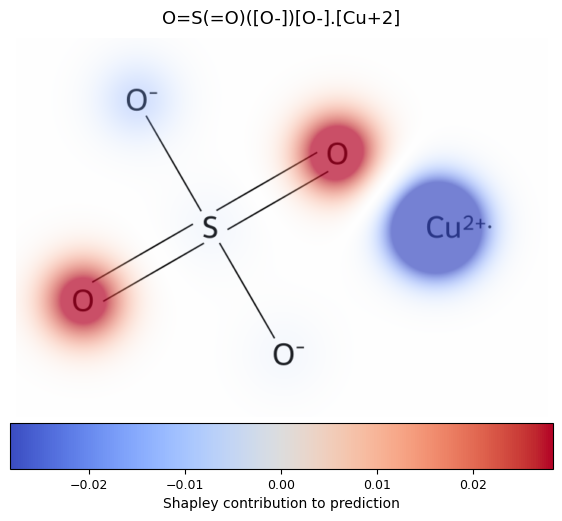

array([ 0.03383762, -0.00630634,  0.03700897, -0.01498241, -0.00606461,
       -0.06038771])

In [21]:
graph = graphs[1003].to(device)

if not hasattr(graph, "batch") or graph.batch is None:
    graph.batch = torch.zeros(graph.x.size(0), dtype=torch.long, device=graph.x.device)

explanation = explainer(
    graph.x,
    graph.edge_index,
    edge_attr=graph.edge_attr,
    virtual_edge_index=graph.virtual_edge_index,
    virtual_edge_attr=graph.virtual_edge_attr,
    fragment_id=graph.fragment_id,
    batch=graph.batch,
)

scores = draw_atom_heatmap_gaussian(
    graph.smiles,
    explanation,
    reduce="sum_abs",
    cmap_name="plasma",
    sigma_frac=0.1,
    alpha=0.90,
)

feature_index, feature_blocks = build_atom_feature_index(graph_featurizer.atom_features) # For decoding features

feature_index, feature_blocks = plot_node_feature_importance(explanation, graph, feature_index, top_n=15, figsize=(15, 6))


shapley = atom_shapley_random(model, graph)

draw_atom_shapley_heatmap_gaussian(
    graph.smiles,
    shapley,
    cmap_name="coolwarm",
    sigma_frac=0.07,
    save_path="atom_shapley_heatmap.png",
)

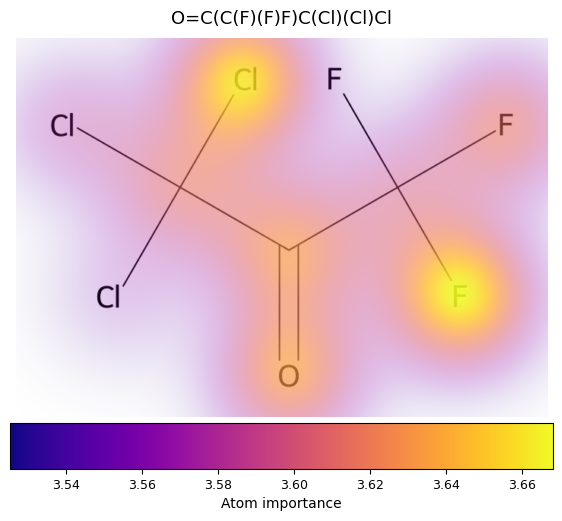

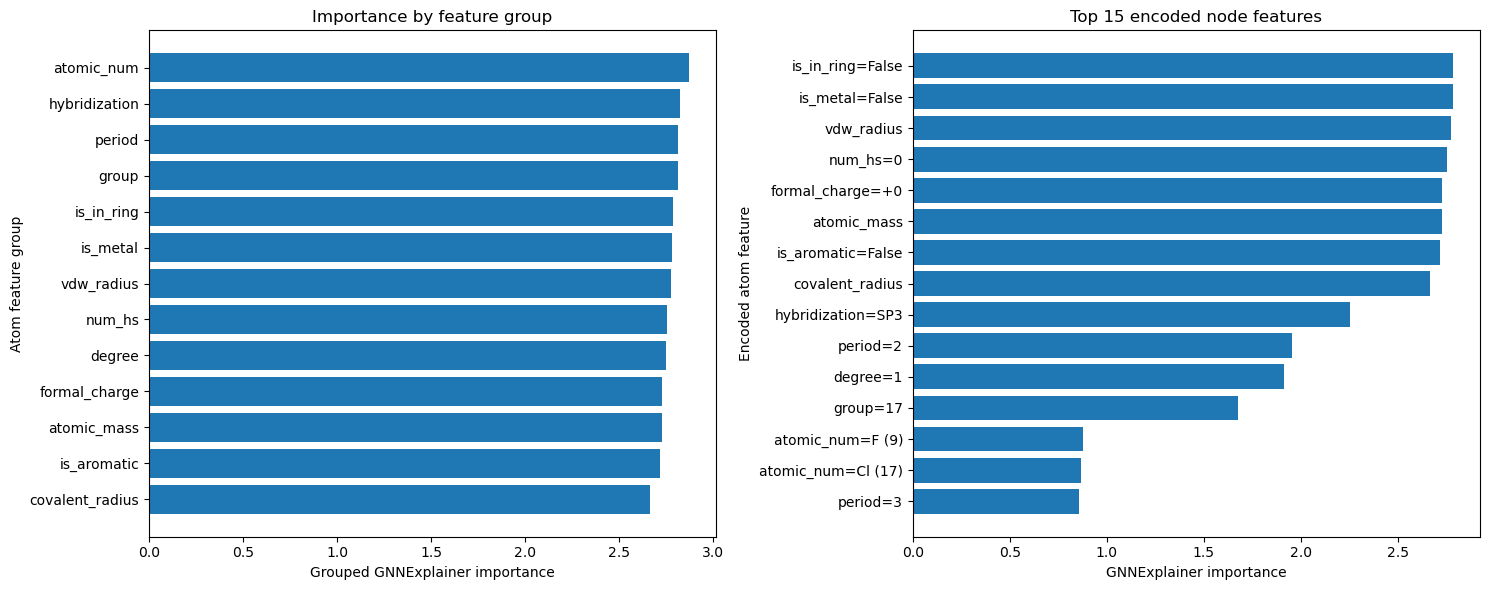

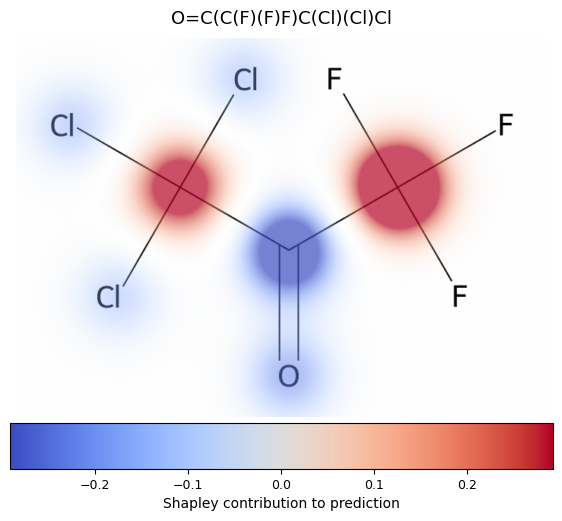

array([-2.20999941e-01, -4.11888689e-01,  5.34295380e-01,  3.28703295e-03,
       -1.01849837e-02,  6.55069234e-05,  3.84026319e-01, -1.72697872e-01,
       -1.61546052e-01, -1.67922676e-01])

In [22]:
graph = graphs[9997].to(device)

if not hasattr(graph, "batch") or graph.batch is None:
    graph.batch = torch.zeros(graph.x.size(0), dtype=torch.long, device=graph.x.device)

explanation = explainer(
    graph.x,
    graph.edge_index,
    edge_attr=graph.edge_attr,
    virtual_edge_index=graph.virtual_edge_index,
    virtual_edge_attr=graph.virtual_edge_attr,
    fragment_id=graph.fragment_id,
    batch=graph.batch,
)

scores = draw_atom_heatmap_gaussian(
    graph.smiles,
    explanation,
    reduce="sum_abs",
    cmap_name="plasma",
    sigma_frac=0.1,
    alpha=0.90,
)

feature_index, feature_blocks = build_atom_feature_index(graph_featurizer.atom_features) # For decoding features

feature_index, feature_blocks = plot_node_feature_importance(explanation, graph, feature_index, top_n=15, figsize=(15, 6))


shapley = atom_shapley_random(model, graph)

draw_atom_shapley_heatmap_gaussian(
    graph.smiles,
    shapley,
    cmap_name="coolwarm",
    sigma_frac=0.07,
    save_path="atom_shapley_heatmap.png",
)

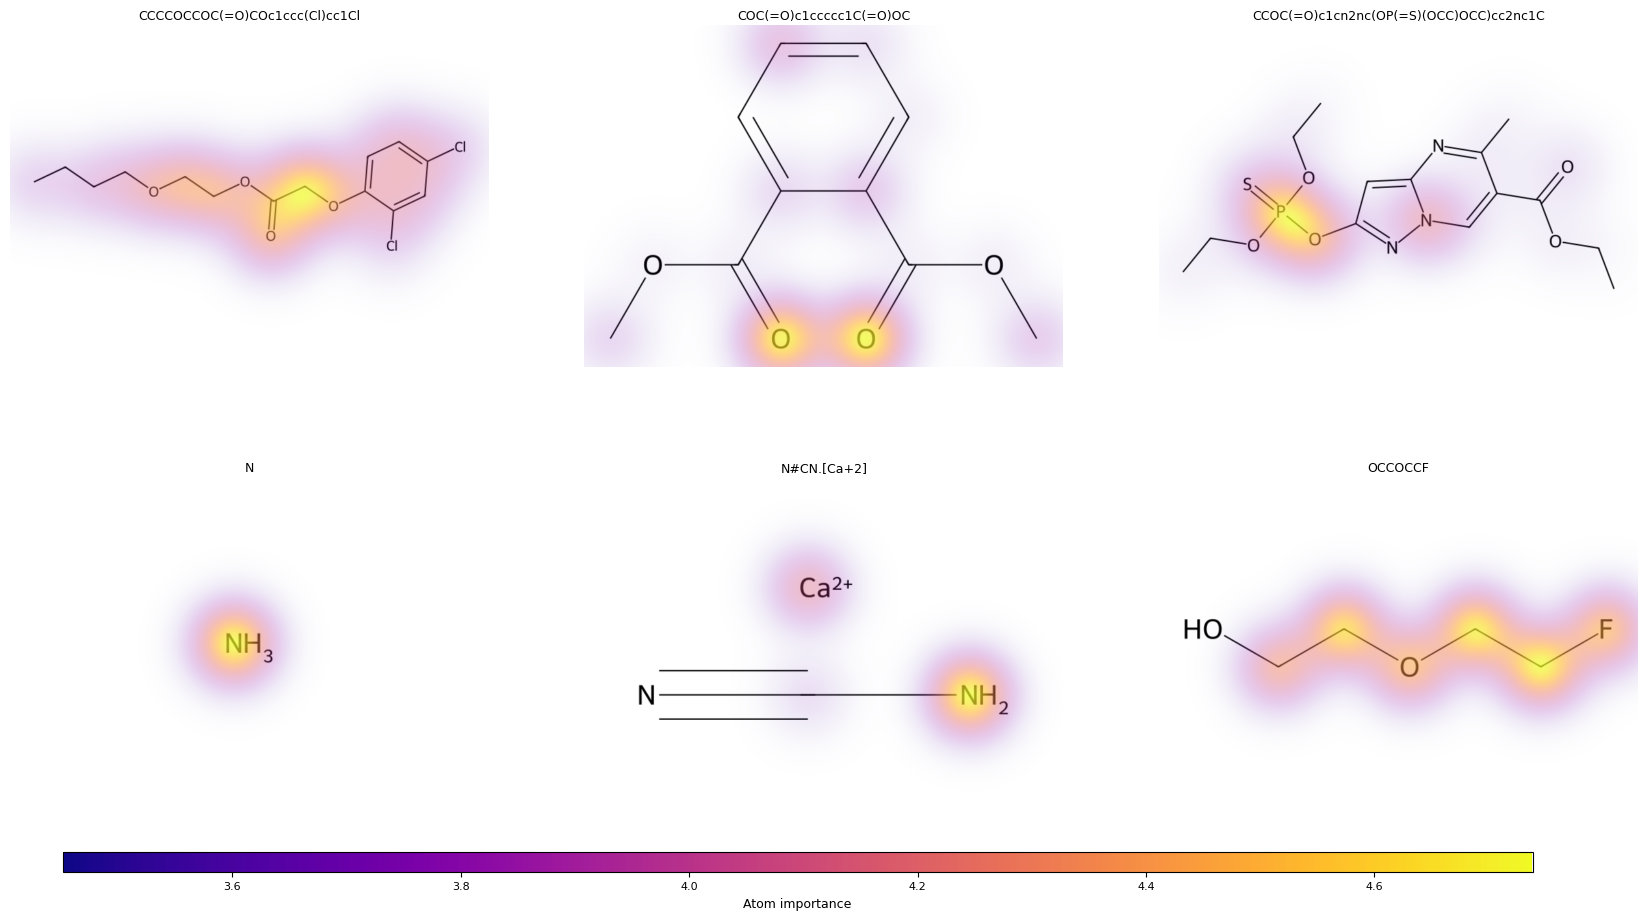

In [24]:
from src.visualization.interpretability import draw_atom_heatmap_grid

draw_atom_heatmap_grid(
    graph_ids=[20, 300, 280, 3, 997, 133],
    dataset=graphs,
    explainer=explainer,
    ncols=3,
    cmap_name="plasma",
    use_percentile=False,
)

## Category sweeps

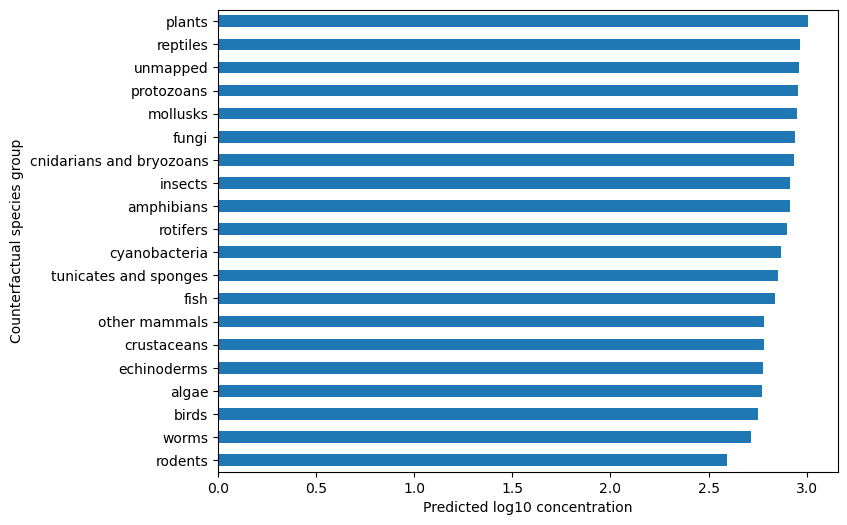

In [ ]:
from src.visualization.interpretability import cat_pred_sweep

row_id = 390
graph = graphs[row_id]

category = "species_group"

cat_sweep_df = cat_pred_sweep(model, graph, category, categorical_encoder, device)

cat_sweep_df.plot.barh(
    x=category,
    y="pred_log10c",
    figsize=(8, 6),
    legend=False,
)
plt.xlabel("Predicted log10 concentration")
plt.ylabel("Counterfactual species group")
plt.show()

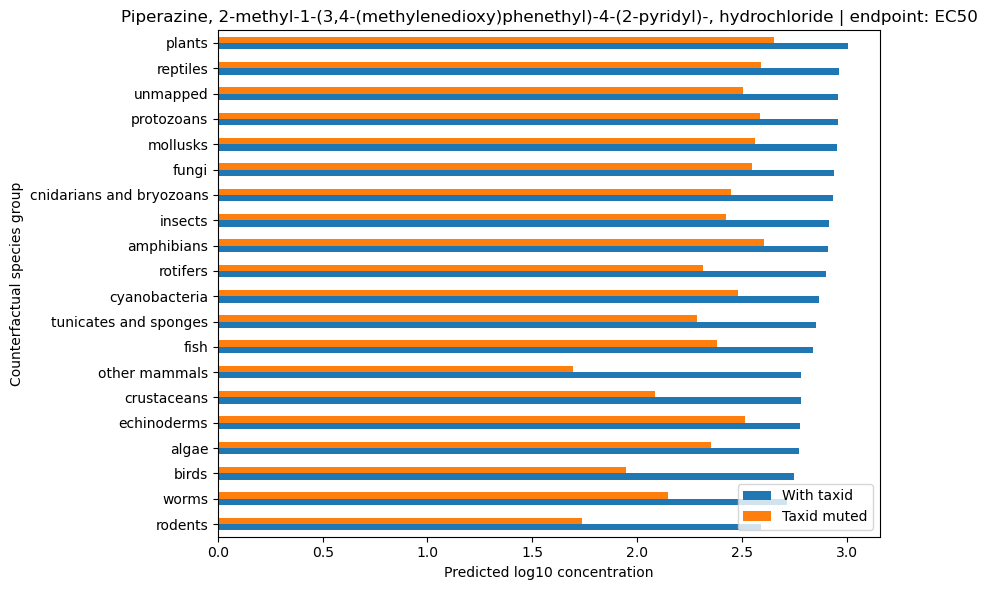

,species_group,species_group_id_with_taxid,pred_log10c_with_taxid,pred_conc_same_unit_with_taxid,delta_log10c_vs_original_with_taxid,original_species_group_with_taxid,species_group_id_no_taxid,pred_log10c_no_taxid,pred_conc_same_unit_no_taxid,delta_log10c_vs_original_no_taxid,original_species_group_no_taxid
0,rodents,5,2.593411,392.113185,0.000000,rodents,5,1.739016,54.829724,0.000000,rodents
1,worms,8,2.716215,520.253647,0.122804,rodents,8,2.145995,139.957243,0.406979,rodents
2,birds,13,2.750705,563.255242,0.157294,rodents,13,1.946893,88.489825,0.207877,rodents
3,algae,10,2.772771,592.612926,0.179360,rodents,10,2.350545,224.153439,0.611529,rodents
4,echinoderms,4,2.775496,596.342836,0.182085,rodents,4,2.513266,326.036398,0.774250,rodents
5,crustaceans,3,2.781243,604.287101,0.187832,rodents,3,2.085947,121.884095,0.346931,rodents
6,other mammals,9,2.782152,605.552357,0.188740,rodents,9,1.693682,49.394896,-0.045334,rodents
7,fish,7,2.837281,687.513872,0.243870,rodents,7,2.379843,239.796586,0.640827,rodents
8,tunicates and sponges,19,2.854630,715.534322,0.261219,rodents,19,2.285781,193.099604,0.546765,rodents
9,cyanobacteria,16,2.867553,737.144717,0.274141,rodents,16,2.483340,304.326344,0.744323,rodents


In [15]:
from src.visualization.interpretability import plot_species_sweep_muted


graph = graphs[390]

comparison = plot_species_sweep_muted(
    model=model,
    graph=graph,
    categorical_encoder=categorical_encoder,
    device=device,
    df=df_processed,
)

comparison

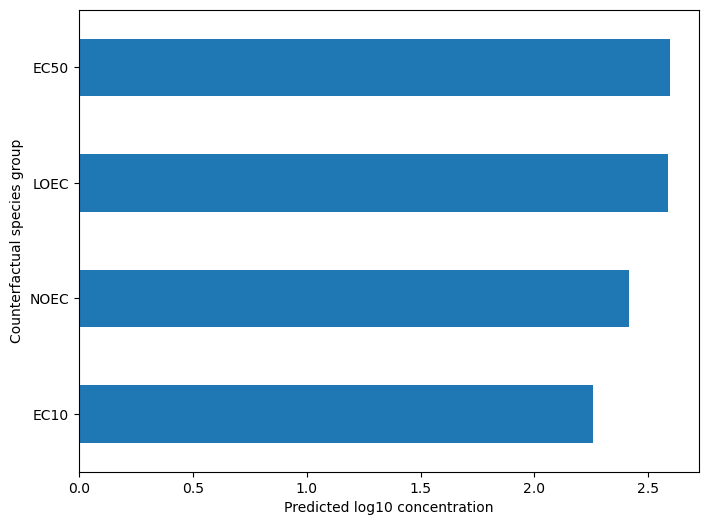

In [16]:
row_id = 390
graph = graphs[row_id]

category = "endpoint"

cat_sweep_df = cat_pred_sweep(model, graph, category, categorical_encoder, device)

cat_sweep_df.plot.barh(
    x=category,
    y="pred_log10c",
    figsize=(8, 6),
    legend=False,
)
plt.xlabel("Predicted log10 concentration")
plt.ylabel("Counterfactual species group")
plt.show()

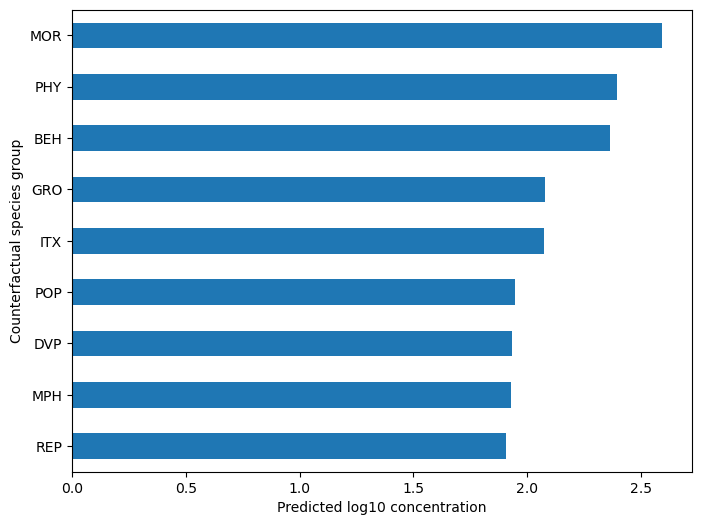

In [17]:
row_id = 390
graph = graphs[row_id]

category = "effect"

cat_sweep_df = cat_pred_sweep(model, graph, category, categorical_encoder, device)

cat_sweep_df.plot.barh(
    x=category,
    y="pred_log10c",
    figsize=(8, 6),
    legend=False,
)
plt.xlabel("Predicted log10 concentration")
plt.ylabel("Counterfactual species group")
plt.show()

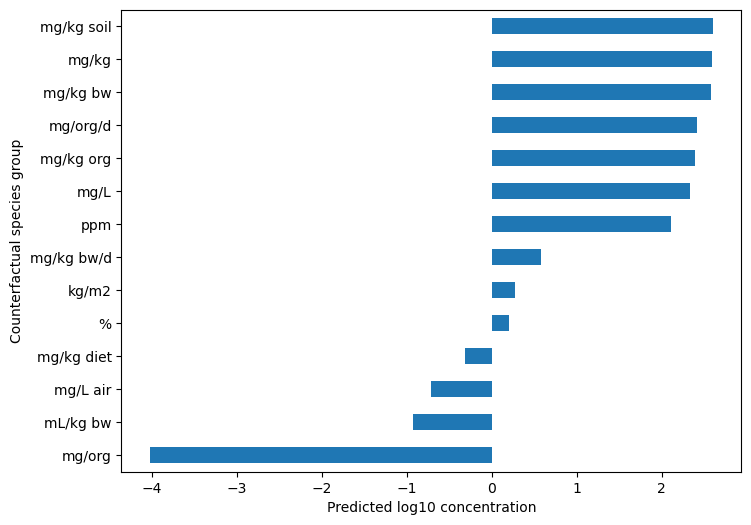

In [18]:
row_id = 390
graph = graphs[row_id]

category = "conc_unit"

cat_sweep_df = cat_pred_sweep(model, graph, category, categorical_encoder, device)

cat_sweep_df.plot.barh(
    x=category,
    y="pred_log10c",
    figsize=(8, 6),
    legend=False,
)
plt.xlabel("Predicted log10 concentration")
plt.ylabel("Counterfactual species group")
plt.show()

## Muted predictions

In [6]:
import torch


def predict_with_metadata_muted(
    model,
    graph,
    device=None,
    categorical_fill=-1,
    numeric_fill=0.0,
    taxid_fill=0,
):
    """
    Compare normal prediction vs prediction after muting metadata fields
    in a cloned graph object.

    categorical_fill=-1 works with your encoders because negative IDs are
    mapped to the last class, usually the unknown/missing bucket.
    """

    def get_device(model):
        try:
            return next(model.parameters()).device
        except StopIteration:
            return torch.device("cpu")

    def infer_metadata_fields(model):
        meta = getattr(model, "meta_encoder", None)
        fields = {
            "taxonomy": [],
            "categorical": [],
            "numeric": [],
            "pretrained_taxid": [],
        }

        if meta is None:
            return fields

        tax_encoder = getattr(meta, "tax_encoder", None)
        if tax_encoder is not None:
            if hasattr(tax_encoder, "embeddings"):
                fields["taxonomy"] += list(tax_encoder.embeddings.keys())
            if hasattr(tax_encoder, "num_classes"):
                fields["taxonomy"] += list(tax_encoder.num_classes.keys())

        categorical_encoder = getattr(meta, "categorical_encoder", None)
        if categorical_encoder is not None and hasattr(categorical_encoder, "num_classes"):
            fields["categorical"] += list(categorical_encoder.num_classes.keys())

        numeric_encoder = getattr(meta, "numeric_encoder", None)
        if numeric_encoder is not None and hasattr(numeric_encoder, "numerical_columns"):
            fields["numeric"] += list(numeric_encoder.numerical_columns)

        pretrained_taxid_encoder = getattr(meta, "pretrained_taxid_encoder", None)
        if pretrained_taxid_encoder is not None:
            fields["pretrained_taxid"].append(pretrained_taxid_encoder.taxid_field)

        return fields

    def set_attr_like(data, attr, fill_value):
        if not hasattr(data, attr):
            return False

        old_value = getattr(data, attr)

        if isinstance(old_value, torch.Tensor):
            if old_value.dtype.is_floating_point:
                new_value = torch.full_like(old_value, float(fill_value))
            else:
                new_value = torch.full_like(old_value, int(fill_value))
        elif isinstance(old_value, list):
            new_value = [fill_value for _ in old_value]
        elif isinstance(old_value, tuple):
            new_value = tuple(fill_value for _ in old_value)
        else:
            new_value = fill_value

        setattr(data, attr, new_value)
        return True

    if device is None:
        device = get_device(model)

    was_training = model.training
    model.eval()

    graph_full = graph.clone().to(device)
    graph_muted = graph.clone()

    metadata_fields = infer_metadata_fields(model)
    muted_fields = []

    for attr in metadata_fields["taxonomy"] + metadata_fields["categorical"]:
        if set_attr_like(graph_muted, attr, categorical_fill):
            muted_fields.append(attr)

    for attr in metadata_fields["numeric"]:
        if set_attr_like(graph_muted, attr, numeric_fill):
            muted_fields.append(attr)

    for attr in metadata_fields["pretrained_taxid"]:
        if set_attr_like(graph_muted, attr, taxid_fill):
            muted_fields.append(attr)

    graph_muted = graph_muted.to(device)

    with torch.no_grad():
        pred_full = model(graph_full).detach().cpu().squeeze()
        pred_muted = model(graph_muted).detach().cpu().squeeze()

    model.train(was_training)

    return {
        "pred_full": pred_full,
        "pred_metadata_muted": pred_muted,
        "delta_full_minus_muted": pred_full - pred_muted,
        "abs_delta": (pred_full - pred_muted).abs(),
        "muted_fields": muted_fields,
    }

In [ ]:
from torch_geometric.data import Batch

graph = Batch.from_data_list([graphs[0]]).to(device)

result = predict_with_metadata_muted(model, graph, device=device)

result

{'pred_full': tensor(1.9086),
 'pred_metadata_muted': tensor(2.0050),
 'delta_full_minus_muted': tensor(-0.0964),
 'abs_delta': tensor(0.0964),
 'muted_fields': ['species_group',
  'conc_unit',
  'endpoint',
  'effect',
  'is_salt',
  'has_metal',
  'is_single_node',
  'fragment_count',
  'log10_mol_weight',
  'formal_charge',
  'taxid_raw']}

In [10]:
print(graph)

DataBatch(x=[24, 187], edge_index=[2, 50], edge_attr=[50, 14], virtual_edge_index=[2, 0], virtual_edge_attr=[0, 10], fragment_id=[24], num_fragments=[1], smiles=[1], y=[1], row_id=[1], taxid_raw=[1], species_group=[1], conc_unit=[1], endpoint=[1], effect=[1], is_salt=[1], has_metal=[1], is_single_node=[1], fragment_count=[1], log10_mol_weight=[1], formal_charge=[1], batch=[24], ptr=[2])
